## Load data and analyze

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
def load_data(path, col_names, datetime_col):
  col_names = col_names
  df = pd.read_csv(path, names=col_names, header=None)
  df[datetime_col] = pd.to_datetime(df[datetime_col])

  return df

In [4]:
path = '/content/drive/MyDrive/dataset/nyctaxi-demand-forecast/nyc_taxi_data_hourly_2024_2025.csv'
col_names = ['zone_id', 'pickup_datetime', 'trip_count']
datetime_col = 'pickup_datetime'
df = load_data(path, col_names, datetime_col)

In [5]:
df.shape

(4418680, 3)

In [6]:
df.head()

,zone_id,pickup_datetime,trip_count
0,264,2024-01-01 03:00:00,18
1,215,2024-01-01 03:00:00,0
2,64,2024-01-01 03:00:00,0
3,110,2024-01-01 03:00:00,0
4,238,2024-01-01 03:00:00,13


In [61]:
zone_df = df[(df['zone_id']==48) | (df['zone_id']==186) | (df['zone_id']==100)]

In [62]:
zone_df.head()

,zone_id,pickup_datetime,trip_count
95,100,2024-01-01 03:00:00,33
177,186,2024-01-01 03:00:00,135
240,48,2024-01-01 03:00:00,210
358,100,2024-01-01 11:00:00,67
440,186,2024-01-01 11:00:00,122


In [63]:
zone_df.sort_values(['zone_id', 'pickup_datetime'], inplace=True)
zone_df.set_index('pickup_datetime', inplace=True)

/tmp/ipykernel_756/3428418963.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zone_df.sort_values(['zone_id', 'pickup_datetime'], inplace=True)


In [64]:
zones = zone_df['zone_id'].unique()

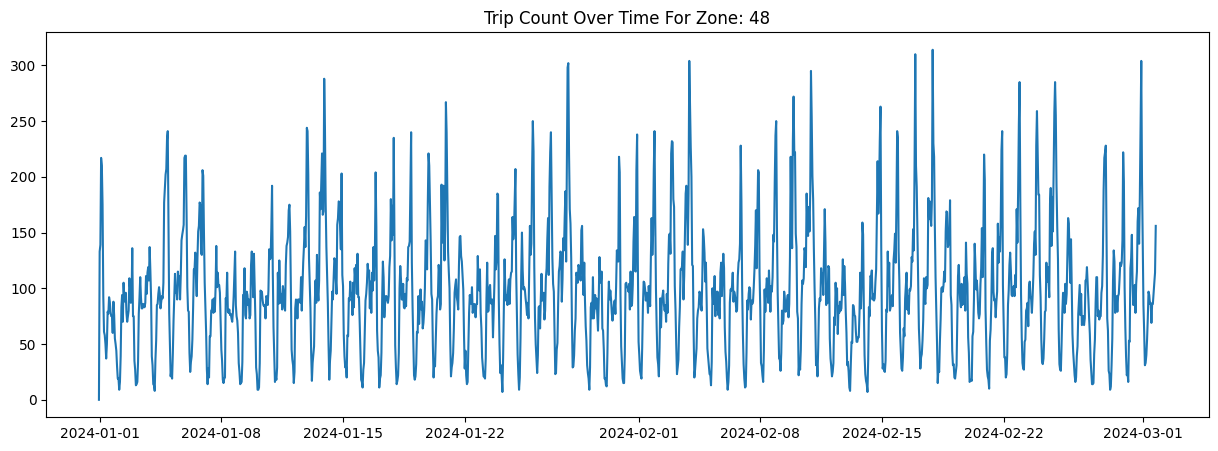

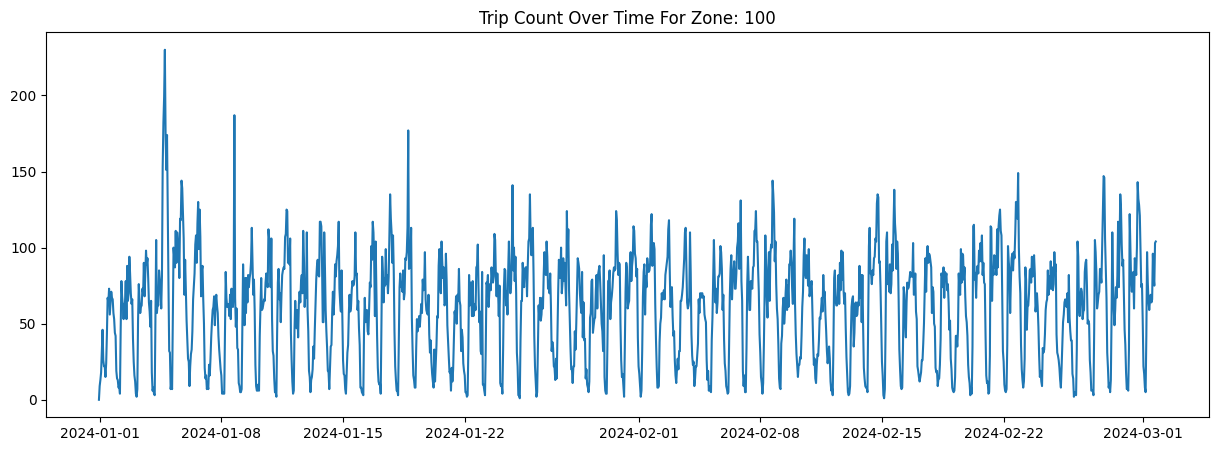

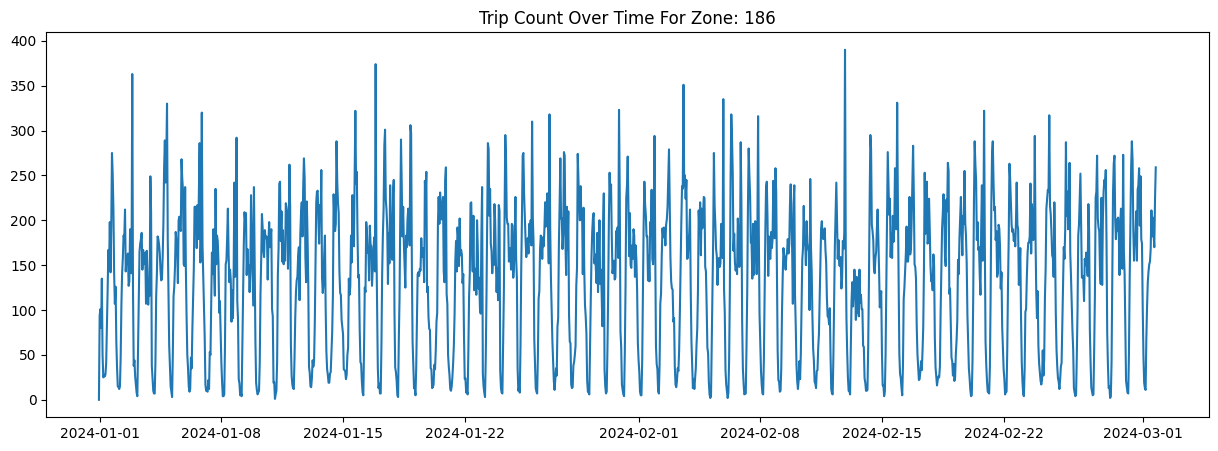

In [11]:
for zone in zones:
  plt.figure(figsize=(15,5))
  plt.plot(zone_df[zone_df['zone_id'] == zone]["trip_count"][:1460])
  plt.title(f"Trip Count Over Time For Zone: {zone}")
  plt.show()

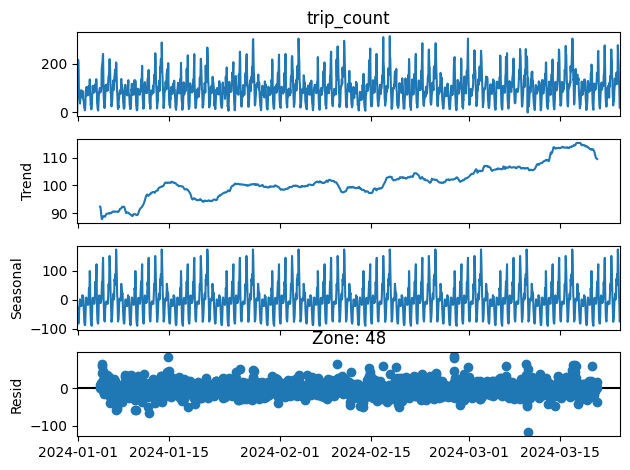

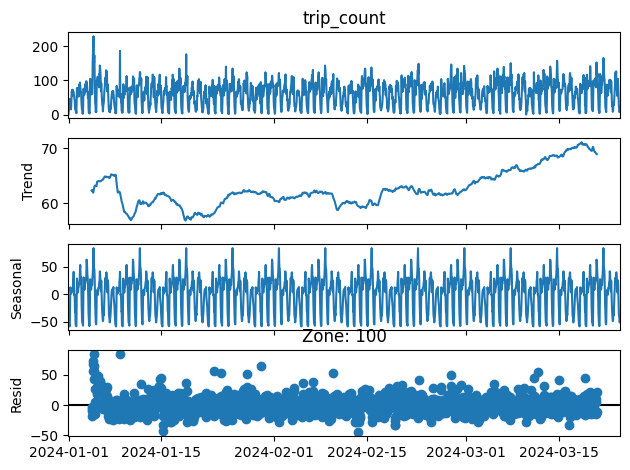

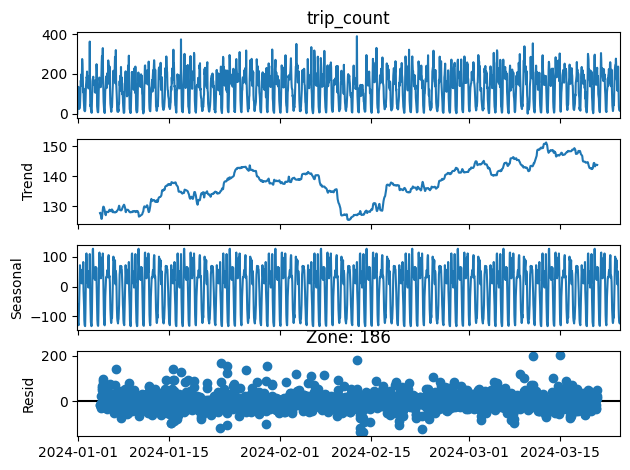

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

for zone in zones:
  decomp = seasonal_decompose(zone_df[zone_df['zone_id'] == zone]["trip_count"][:2000], model="additive", period=168)
  decomp.plot()
  plt.title(f"Zone: {zone}")
  plt.show()

We can see data is seasonal and there is a increasing trend. As this is panel timeseries data, Trees like Random Forest, XGBoost handle this type without much preprocessing of data.

## Data preparing, test train spilt and model training:

In [5]:
df.head()

,zone_id,pickup_datetime,trip_count
0,264,2024-01-01 03:00:00,18
1,215,2024-01-01 03:00:00,0
2,64,2024-01-01 03:00:00,0
3,110,2024-01-01 03:00:00,0
4,238,2024-01-01 03:00:00,13


In [9]:
holidays = pd.read_csv('/content/drive/MyDrive/dataset/nyctaxi-demand-forecast/city_holidays.csv')
holidays = holidays[['holiday_name','holiday_date']]
holidays['holiday_date'] = pd.to_datetime(holidays['holiday_date'])
holidays.head()

,holiday_name,holiday_date
0,New Year's Day,2010-01-01
1,Martin Luther King Jr. Day,2010-01-18
2,Presidents' Day,2010-02-15
3,Memorial Day,2010-05-31
4,Independence Day,2010-07-04


In [7]:
def time_lag_features(df, holidays):

  df = df.copy()
  holidays = holidays.copy()

  # time features
  df["hour"] = df["pickup_datetime"].dt.hour
  df["dayofweek"] = df["pickup_datetime"].dt.dayofweek
  df["dayofmonth"] = df["pickup_datetime"].dt.day
  df["month"] = df["pickup_datetime"].dt.month
  df["quarter"] = df["pickup_datetime"].dt.quarter
  df["year"] = df["pickup_datetime"].dt.year
  df["dayofyear"] = df["pickup_datetime"].dt.dayofyear

  # holiday flag
  df['is_holiday'] = df['pickup_datetime'].dt.date.isin(holidays['holiday_date']).astype(int)

  # lag features (per zone)
  df["lag_1"] = df.groupby("zone_id")["trip_count"].shift(1)
  df["lag_24"] = df.groupby("zone_id")["trip_count"].shift(24)
  df["lag_168"] = df.groupby("zone_id")["trip_count"].shift(168)

  # rolling features (NO leakage)
  df["rolling_avg_24h"] = (
      df.groupby("zone_id")["trip_count"]
        .transform(lambda x: x.shift(1).rolling(24).mean())
  )

  df["rolling_avg_7d"] = (
      df.groupby("zone_id")["trip_count"]
        .transform(lambda x: x.shift(1).rolling(168).mean())
  )

  df["rolling_std_24h"] = (
      df.groupby("zone_id")["trip_count"]
        .transform(lambda x: x.shift(1).rolling(24).std())
  )

  df = df.dropna()

  return df

In [10]:
df = time_lag_features(df, holidays)
df.head()

,zone_id,pickup_datetime,trip_count,hour,dayofweek,dayofmonth,month,quarter,year,dayofyear,is_holiday,lag_1,lag_24,lag_168,rolling_avg_24h,rolling_avg_7d,rolling_std_24h
44184,264,2024-02-26 03:00:00,0,3,0,26,2,1,2024,57,0,7.0,17.0,18.0,12.250000,11.815476,9.391254
44185,215,2024-02-26 03:00:00,0,3,0,26,2,1,2024,57,0,1.0,0.0,0.0,0.500000,0.553571,0.884652
44186,64,2024-02-26 03:00:00,0,3,0,26,2,1,2024,57,0,0.0,0.0,0.0,0.041667,0.035714,0.204124
44187,110,2024-02-26 03:00:00,0,3,0,26,2,1,2024,57,0,0.0,0.0,0.0,0.000000,0.000000,0.000000
44188,238,2024-02-26 03:00:00,2,3,0,26,2,1,2024,57,0,90.0,4.0,13.0,70.625000,76.238095,53.852304


In [11]:
train = df[df["pickup_datetime"] < "2025-08-31"]
test = df[df["pickup_datetime"] >= "2025-08-31"]

In [156]:
df.columns

Index(['zone_id', 'pickup_datetime', 'trip_count', 'hour', 'dayofweek',
       'dayofmonth', 'month', 'quarter', 'year', 'dayofyear', 'is_holiday',
       'lag_1', 'lag_24', 'lag_168', 'rolling_avg_24h', 'rolling_avg_7d',
       'rolling_std_24h'],
      dtype='object')

###XGBoost


In [11]:
features = ['zone_id', 'hour', 'dayofweek',
            'dayofmonth', 'month', 'quarter', 'year', 'dayofyear', 'is_holiday',
            'lag_1', 'lag_24', 'lag_168', 'rolling_avg_24h', 'rolling_avg_7d',
            'rolling_std_24h']

target = 'trip_count'

In [163]:
# model
from xgboost import XGBRegressor

model = XGBRegressor()

model.fit(train[features], train[target])



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [164]:
forecast = model.predict(test[features])

In [165]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test["trip_count"], forecast)
rmse = np.sqrt(mean_squared_error(test["trip_count"], forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 3.9418773651123047
RMSE: 12.365468062917758


In [166]:
test["prediction"] = forecast

/tmp/ipykernel_23744/1882669308.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["prediction"] = forecast


/tmp/ipykernel_23744/4004344676.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zone_test.sort_values(['zone_id', 'pickup_datetime'], inplace=True)
/tmp/ipykernel_23744/4004344676.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zone_test["pickup_datetime"] = pd.to_datetime(zone_test["pickup_datetime"])


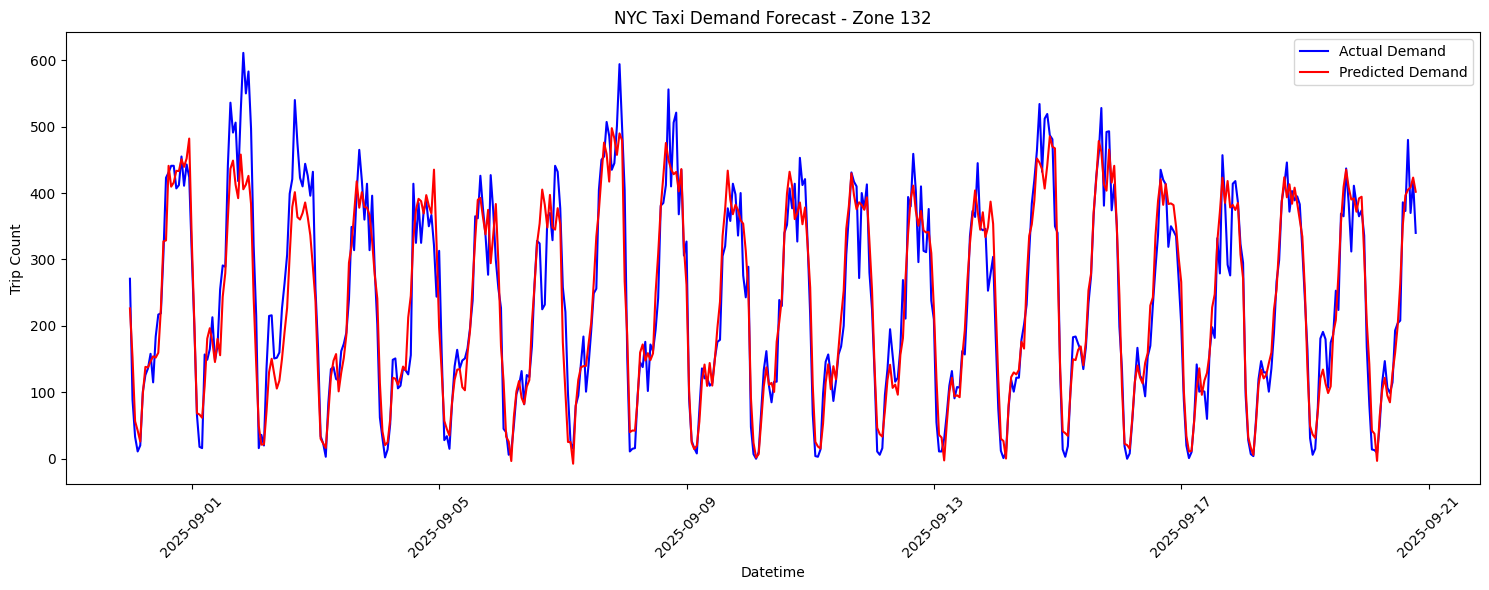

In [167]:
zone_id = 132
zone_test = test[test["zone_id"] == zone_id]
zone_test.sort_values(['zone_id', 'pickup_datetime'], inplace=True)
zone_test["pickup_datetime"] = pd.to_datetime(zone_test["pickup_datetime"])
zone_test.set_index('pickup_datetime', inplace=True)

plt.figure(figsize=(15,6))

plt.plot(zone_test["trip_count"][:500],
         label="Actual Demand", color="blue")

plt.plot(zone_test["prediction"][:500],
         label="Predicted Demand", color="red")

plt.title(f"NYC Taxi Demand Forecast - Zone {zone_id}")
plt.xlabel("Datetime")
plt.ylabel("Trip Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_23744/3355382.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zone_test.sort_values(['zone_id', 'pickup_datetime'], inplace=True)
/tmp/ipykernel_23744/3355382.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zone_test["pickup_datetime"] = pd.to_datetime(zone_test["pickup_datetime"])


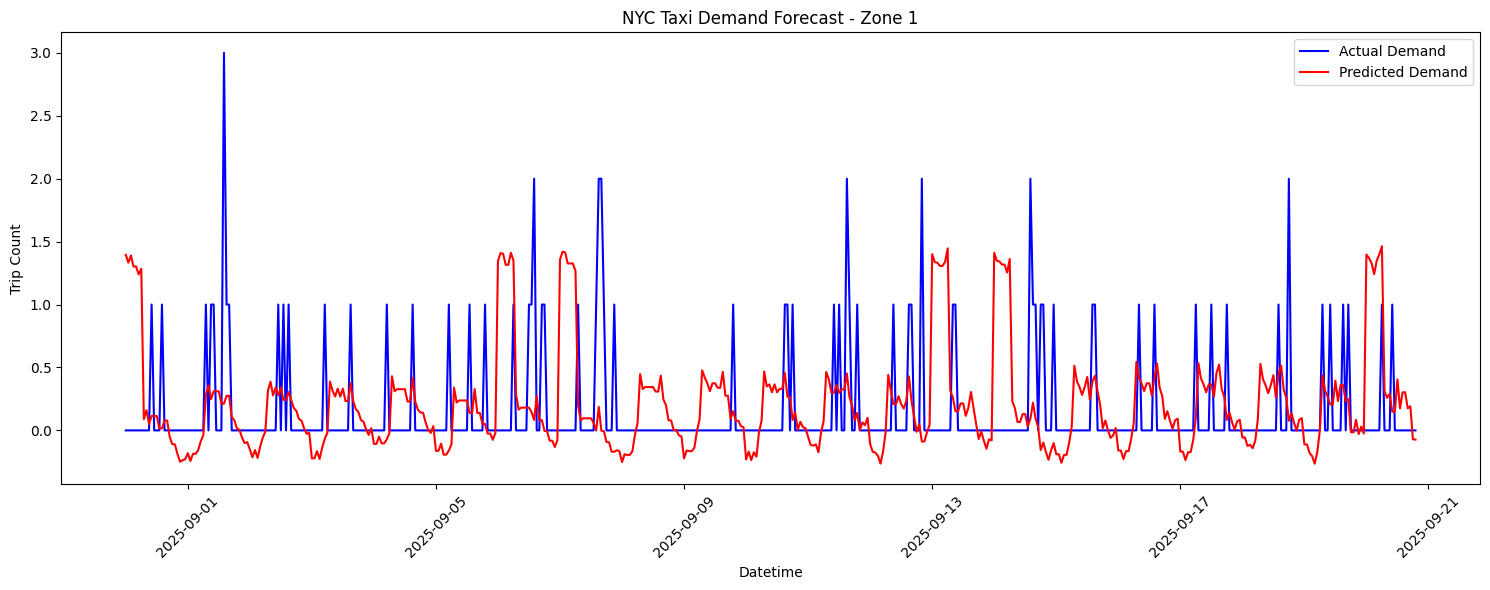

In [168]:
zone_id = 1
zone_test = test[test["zone_id"] == zone_id]
zone_test.sort_values(['zone_id', 'pickup_datetime'], inplace=True)
zone_test["pickup_datetime"] = pd.to_datetime(zone_test["pickup_datetime"])
zone_test.set_index('pickup_datetime', inplace=True)

plt.figure(figsize=(15,6))

plt.plot(zone_test["trip_count"][:500],
         label="Actual Demand", color="blue")

plt.plot(zone_test["prediction"][:500],
         label="Predicted Demand", color="red")

plt.title(f"NYC Taxi Demand Forecast - Zone {zone_id}")
plt.xlabel("Datetime")
plt.ylabel("Trip Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_756/3655956302.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zone_test.sort_values(['zone_id', 'pickup_datetime'], inplace=True)
/tmp/ipykernel_756/3655956302.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zone_test["pickup_datetime"] = pd.to_datetime(zone_test["pickup_datetime"])


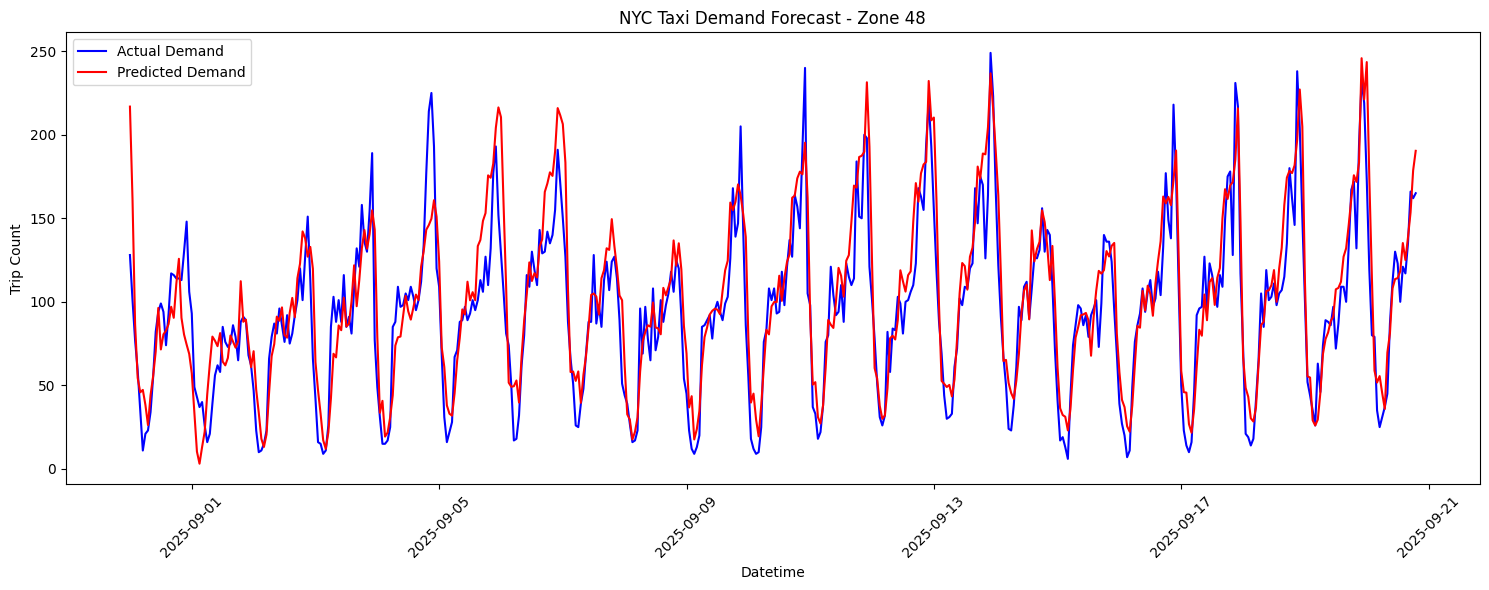

In [87]:
zone_id = 48
zone_test = test[test["zone_id"] == zone_id]
zone_test.sort_values(['zone_id', 'pickup_datetime'], inplace=True)
zone_test["pickup_datetime"] = pd.to_datetime(zone_test["pickup_datetime"])
zone_test.set_index('pickup_datetime', inplace=True)

plt.figure(figsize=(15,6))

plt.plot(zone_test["trip_count"][:500],
         label="Actual Demand", color="blue")

plt.plot(zone_test["prediction"][:500],
         label="Predicted Demand", color="red")

plt.title(f"NYC Taxi Demand Forecast - Zone {zone_id}")
plt.xlabel("Datetime")
plt.ylabel("Trip Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [169]:
pd.DataFrame(data=model.feature_importances_,
             index=model.feature_names_in_,
             columns=['Importance']).sort_values('Importance', ascending=False)

,Importance
rolling_avg_7d,0.780312
hour,0.099714
dayofweek,0.032375
zone_id,0.023752
rolling_avg_24h,0.020001
rolling_std_24h,0.011953
lag_1,0.010296
dayofyear,0.009137
month,0.004144
dayofmonth,0.003721


### LightGBM

In [158]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor()
lgb_model.fit(train[features], train[target])



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.183471 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2112
[LightGBM] [Info] Number of data points in the train set: 3793792, number of used features: 14
[LightGBM] [Info] Start training from score 15.324397


LGBMRegressor()

In [159]:
forecast_lgb = lgb_model.predict(test[features])

In [160]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test["trip_count"], forecast_lgb)
rmse = np.sqrt(mean_squared_error(test["trip_count"], forecast_lgb))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4.430422664360683
RMSE: 13.497517731896892


In [161]:
test["prediction_2"] = forecast_lgb

/tmp/ipykernel_23744/3875849798.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["prediction_2"] = forecast_lgb


/tmp/ipykernel_23744/2400869037.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zone_test.sort_values(['zone_id', 'pickup_datetime'], inplace=True)
/tmp/ipykernel_23744/2400869037.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zone_test["pickup_datetime"] = pd.to_datetime(zone_test["pickup_datetime"])


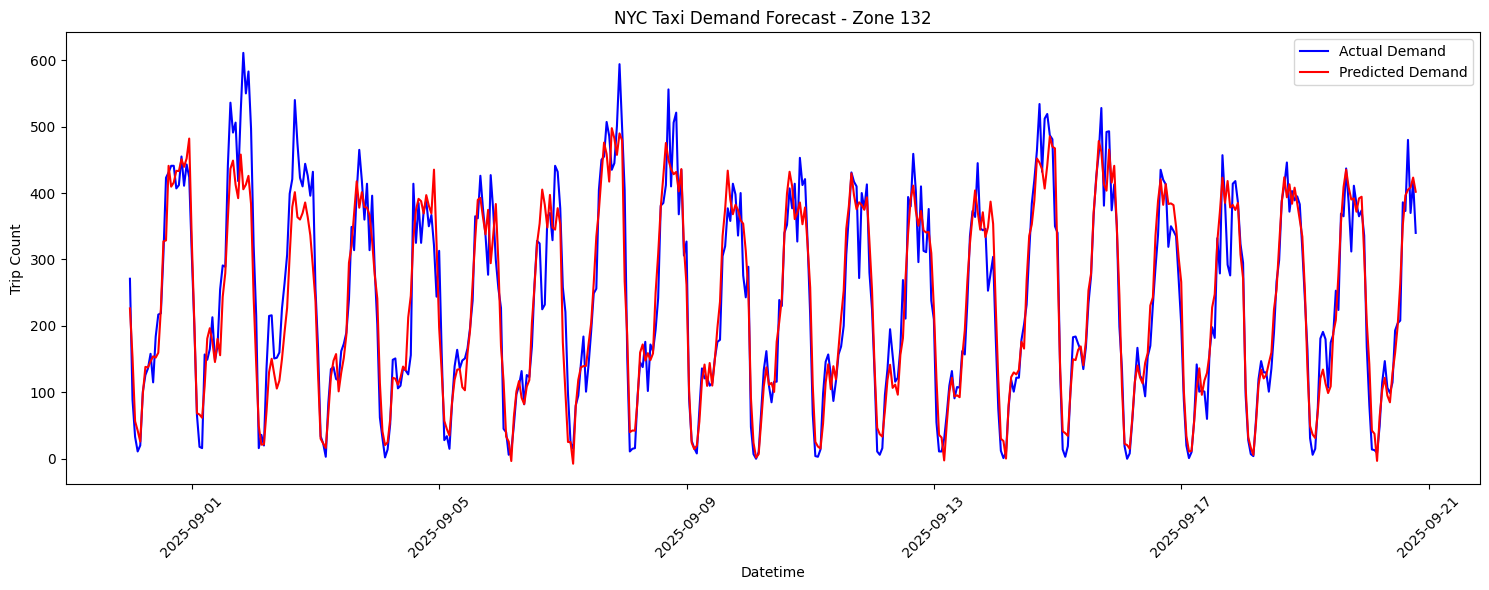

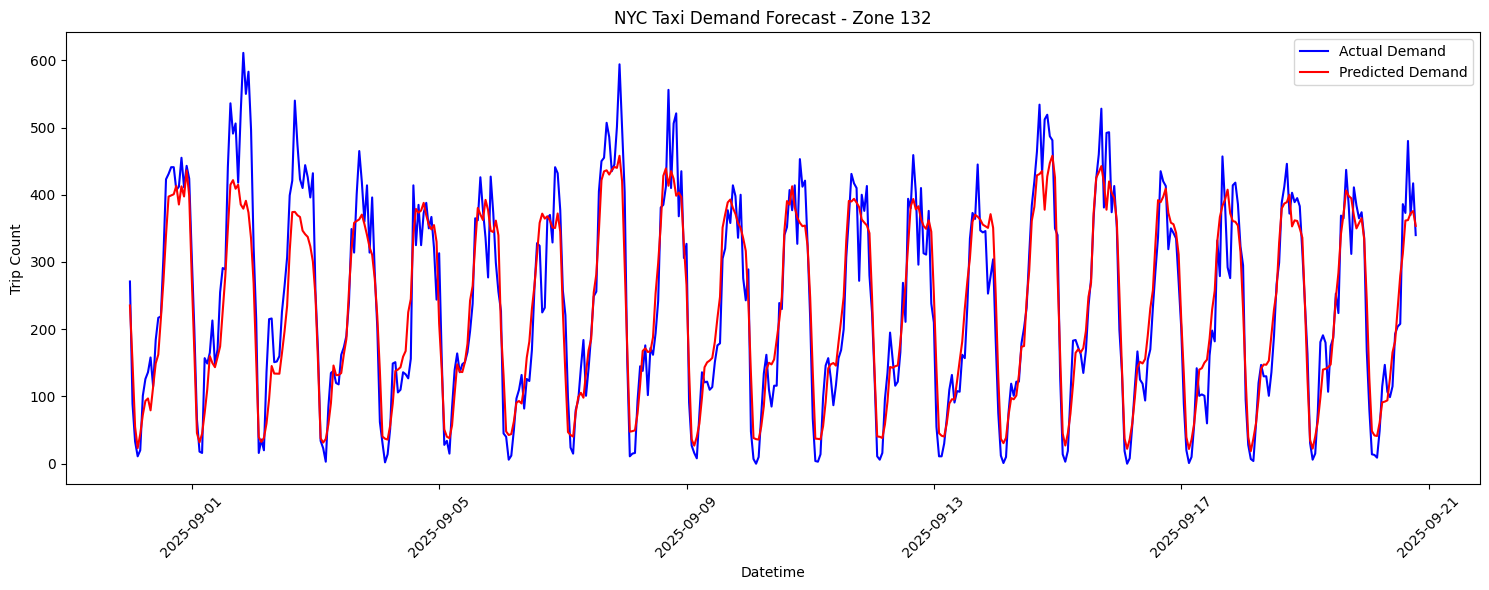

In [170]:
zone_id = 132
zone_test = test[test["zone_id"] == zone_id]
zone_test.sort_values(['zone_id', 'pickup_datetime'], inplace=True)
zone_test["pickup_datetime"] = pd.to_datetime(zone_test["pickup_datetime"])
zone_test.set_index('pickup_datetime', inplace=True)

for p in ['prediction', 'prediction_2']:
  plt.figure(figsize=(15,6))

  plt.plot(zone_test["trip_count"][:500],
          label="Actual Demand", color="blue")

  plt.plot(zone_test[p][:500],
          label="Predicted Demand", color="red")

  plt.title(f"NYC Taxi Demand Forecast - Zone {zone_id}")
  plt.xlabel("Datetime")
  plt.ylabel("Trip Count")
  plt.legend()
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

In [ ]:
# above - graph 1 comapre real value with prediction from xgboost
# above - graph 1 comapre real value with prediction from Lightgbm

In [171]:
pd.DataFrame(data=lgb_model.feature_importances_,
             index=lgb_model.feature_names_in_,
             columns=['Importance']).sort_values('Importance', ascending=False)

,Importance
zone_id,871
hour,698
dayofweek,463
rolling_avg_7d,376
dayofyear,264
rolling_std_24h,106
lag_1,94
dayofmonth,51
rolling_avg_24h,43
month,16


## Hyperparameter tuning XGBoost model

In [14]:
from sklearn.model_selection import RandomizedSearchCV


In [15]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [118]:
xgb_params = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "gamma": [0, 0.1, 0.3],
    "min_child_weight": [1, 3, 5]
}

In [119]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

In [126]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_params,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=2,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9],
                                        'gamma': [0, 0.1, 0.3],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [4, 6, 8, 10],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 400, 600, 800],
                                        'subsample': [0.7, 0.8, 0.9]},
                   scoring='neg_root_mean_squared_error', verbose=2)

In [127]:
print("Best XGBoost Params:", xgb_search.best_params_)

Best XGBoost Params: {'subsample': 0.7, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.9}


In [130]:
best_xgb = xgb_search.best_estimator_

In [139]:
xgb_preds = best_xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
print("XGBoost RMSE:", rmse)

XGBoost RMSE: 10.590692759792638


Train with best parameters

In [173]:
from xgboost import XGBRegressor

best_model = XGBRegressor(
    subsample=0.7,
    n_estimators=600,
    min_child_weight=3,
    max_depth=10,
    learning_rate=0.03,
    gamma=0.3,
    colsample_bytree=0.9
)

best_model.fit(train[features], train[target])




XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.3, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=600,
             n_jobs=None, num_parallel_tree=None, ...)

In [178]:
feature_names = features
importance_scores = best_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance_scores})
feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)
print(feature_importance_df)

            Feature  Importance
13   rolling_avg_7d    0.672808
12  rolling_avg_24h    0.113117
1              hour    0.106389
0           zone_id    0.033184
2         dayofweek    0.026607
14  rolling_std_24h    0.011461
9             lag_1    0.009334
7         dayofyear    0.008997
4             month    0.005615
5           quarter    0.003244
3        dayofmonth    0.003232
6              year    0.002805
11          lag_168    0.001611
10           lag_24    0.001596
8        is_holiday    0.000000


## Recursive Forecast  

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [14]:
def recursive_forecast(df, model, hours_to_predict):

    df = df.copy()
    df = df.sort_values(['zone_id','pickup_datetime'])

    predictions = []

    last_time = df.pickup_datetime.max()
    zones = df.zone_id.unique()

    for step in range(hours_to_predict):

        next_time = last_time + pd.Timedelta(hours=1)

        future_rows = []

        for zone in [1, 48, 100]:

            zone_df = df[df.zone_id == zone]

            # Lag features
            lag_1 = zone_df.iloc[-1]['trip_count']
            lag_24 = zone_df.iloc[-24]['trip_count']
            lag_168 = zone_df.iloc[-168]['trip_count']

            # Rolling features
            rolling_avg_24h = zone_df.tail(24)['trip_count'].mean()
            rolling_std_24h = zone_df.tail(24)['trip_count'].std()

            rolling_avg_7d = zone_df.tail(168)['trip_count'].mean()

            # features = ['zone_id', 'hour', 'dayofweek',
            # 'dayofmonth', 'month', 'quarter', 'year', 'dayofyear', 'is_holiday',
            # 'lag_1', 'lag_24', 'lag_168', 'rolling_avg_24h', 'rolling_avg_7d',
            # 'rolling_std_24h']


            future_rows.append({
                "zone_id": zone,
                ##"pickup_hour": next_time,
                "hour": next_time.hour,
                "dayofweek": next_time.dayofweek,
                'dayofmonth': next_time.day,
                "month": next_time.month,
                "quarter": next_time.quarter,
                "year": next_time.year,
                "dayofyear": next_time.dayofyear,
                "is_holiday": 0,
                "lag_1": lag_1,
                "lag_24": lag_24,
                "lag_168": lag_168,
                "rolling_avg_24h": rolling_avg_24h,
                "rolling_std_24h": rolling_std_24h,
                "rolling_avg_7d": rolling_avg_7d
            })



        future_df = pd.DataFrame(future_rows)

        preds = model.predict(future_df[features])

        future_df["predicted_trip_count"] = preds

        # Append predictions to history
        df = pd.concat([df, future_df], ignore_index=True)

        predictions.append(future_df)

        last_time = next_time

    predictions = pd.concat(predictions)

    return predictions

In [182]:
forecast_7d = recursive_forecast(train, best_model, 169)

In [138]:
forecast_7d.head(10)

,zone_id,hour,dayofweek,month,quarter,year,dayofyear,is_holiday,lag_1,lag_24,lag_168,rolling_avg_24h,rolling_std_24h,rolling_avg_7d,predicted_trip_count
0,1,0,6,8,3,2025,243,0,0.0,0.0,1.0,0.291667,0.750604,0.190476,1.525354
1,48,0,6,8,3,2025,243,0,150.0,110.0,147.0,94.541667,54.440218,81.898810,160.045314
2,100,0,6,8,3,2025,243,0,99.0,54.0,53.0,54.625000,32.235293,56.327381,83.261786
0,1,1,6,8,3,2025,243,0,NaN,0.0,0.0,0.304348,0.764840,0.185629,0.155928
1,48,1,6,8,3,2025,243,0,NaN,89.0,111.0,93.869565,55.561845,81.508982,128.505876
2,100,1,6,8,3,2025,243,0,NaN,40.0,25.0,54.652174,32.959491,56.347305,71.190910
0,1,2,6,8,3,2025,243,0,NaN,0.0,0.0,0.318182,0.779888,0.186747,0.155928
1,48,2,6,8,3,2025,243,0,NaN,51.0,72.0,94.090909,56.858981,81.331325,82.907799
2,100,2,6,8,3,2025,243,0,NaN,13.0,28.0,55.318182,33.576333,56.536145,55.934023
0,1,3,6,8,3,2025,243,0,NaN,0.0,0.0,0.333333,0.795822,0.187879,1.477550


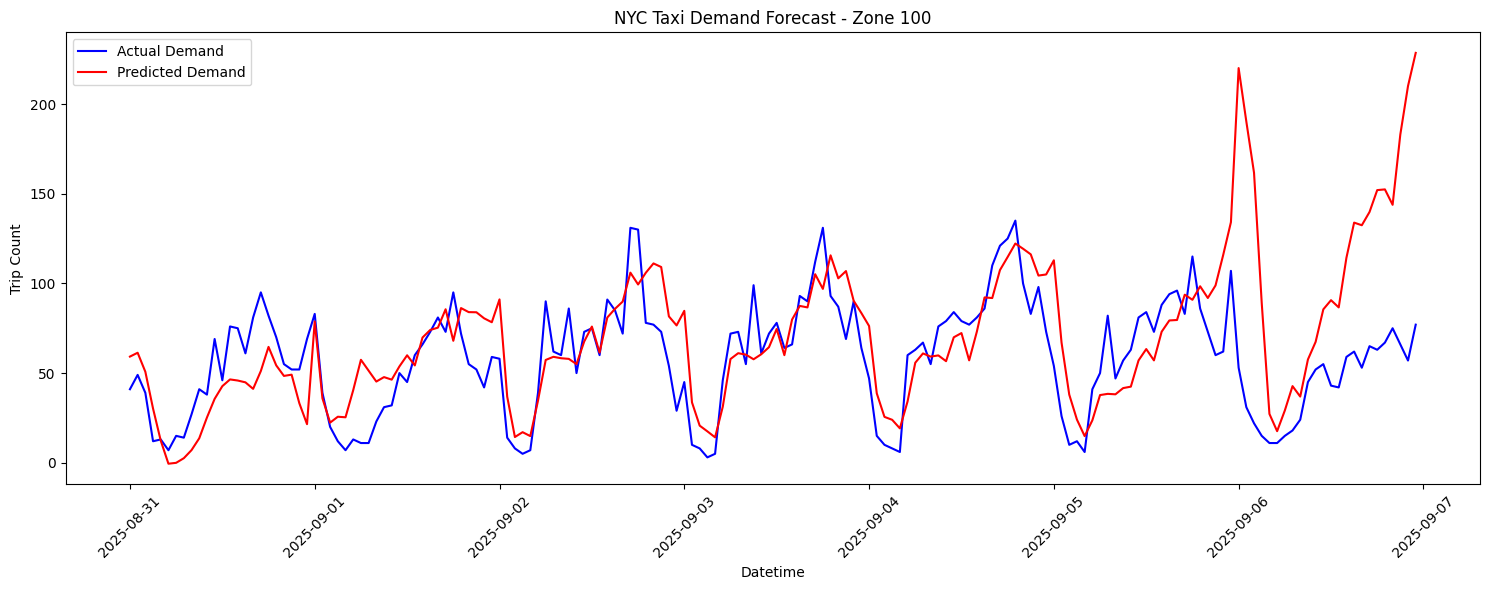

In [184]:
zone_id = 100
zone_test = test[test["zone_id"] == zone_id][['zone_id', 'pickup_datetime', 'trip_count']]
zone_test.sort_values(['zone_id', 'pickup_datetime'], inplace=True)
zone_test["pickup_datetime"] = pd.to_datetime(zone_test["pickup_datetime"])
zone_test = zone_test[:168]
zone_test.reset_index(drop=True, inplace=True)
forecast_7d_copy = forecast_7d[forecast_7d["zone_id"] == zone_id]["predicted_trip_count"].copy()
forecast_7d_copy.reset_index(drop=True, inplace=True)
zone_test["predicted_trip_count"] = forecast_7d_copy
zone_test.set_index('pickup_datetime', inplace=True)


plt.figure(figsize=(15,6))

plt.plot(zone_test["trip_count"],
         label="Actual Demand", color="blue")

plt.plot(zone_test["predicted_trip_count"],
         label="Predicted Demand", color="red")

plt.title(f"NYC Taxi Demand Forecast - Zone {zone_id}")
plt.xlabel("Datetime")
plt.ylabel("Trip Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

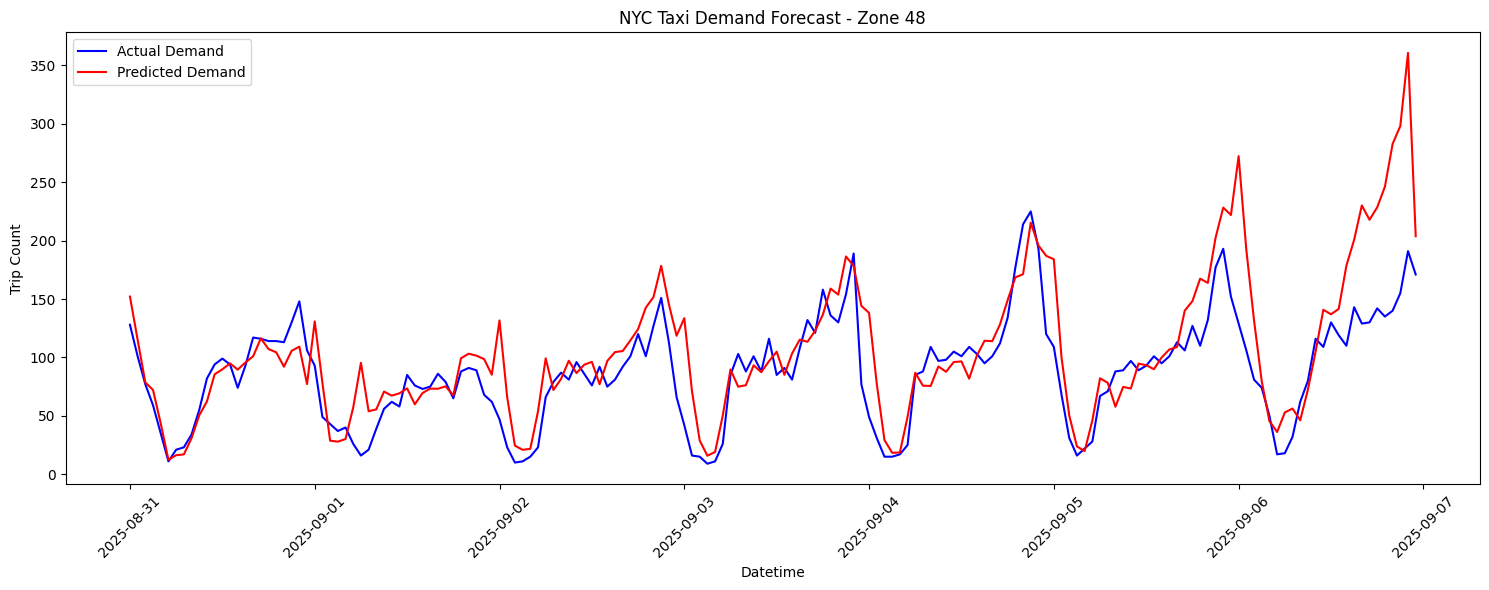

In [186]:
zone_id = 48
zone_test = test[test["zone_id"] == zone_id][['zone_id', 'pickup_datetime', 'trip_count']]
zone_test.sort_values(['zone_id', 'pickup_datetime'], inplace=True)
zone_test["pickup_datetime"] = pd.to_datetime(zone_test["pickup_datetime"])
zone_test = zone_test[:168]
zone_test.reset_index(drop=True, inplace=True)
forecast_7d_copy = forecast_7d[forecast_7d["zone_id"] == zone_id]["predicted_trip_count"].copy()
forecast_7d_copy.reset_index(drop=True, inplace=True)
zone_test["predicted_trip_count"] = forecast_7d_copy
zone_test.set_index('pickup_datetime', inplace=True)


plt.figure(figsize=(15,6))

plt.plot(zone_test["trip_count"],
         label="Actual Demand", color="blue")

plt.plot(zone_test["predicted_trip_count"],
         label="Predicted Demand", color="red")

plt.title(f"NYC Taxi Demand Forecast - Zone {zone_id}")
plt.xlabel("Datetime")
plt.ylabel("Trip Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

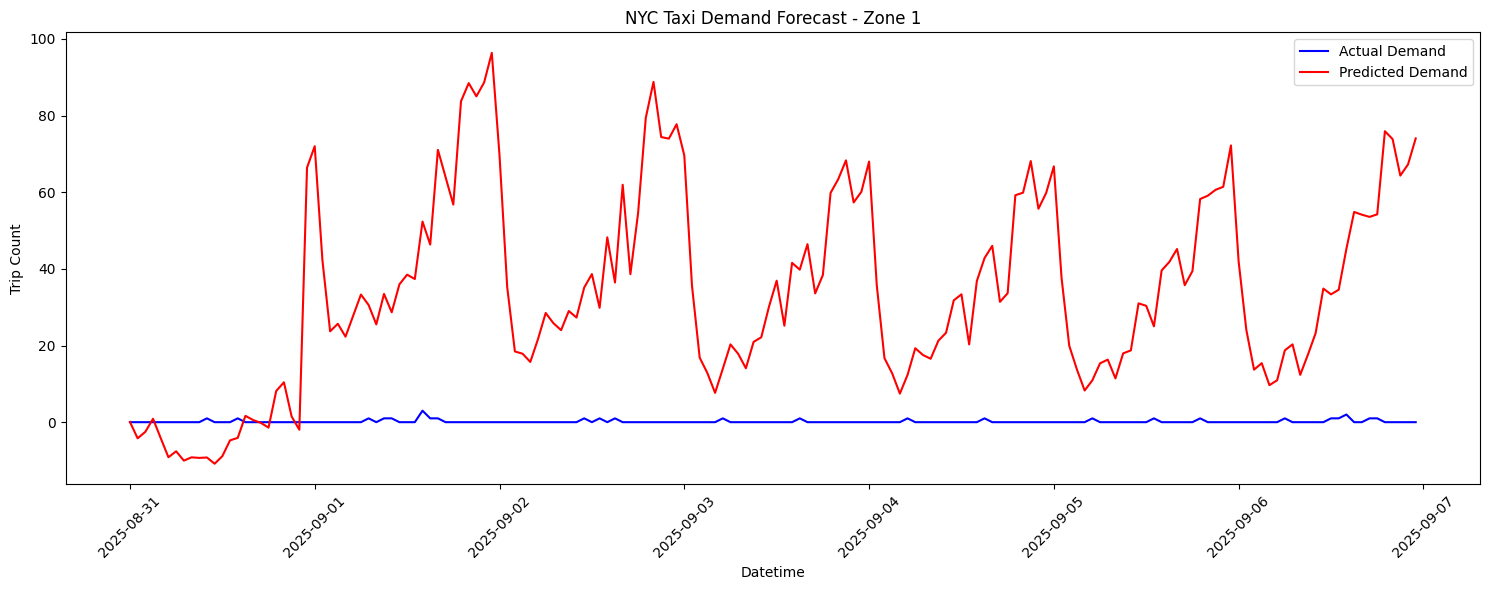

In [185]:
zone_id = 1
zone_test = test[test["zone_id"] == zone_id][['zone_id', 'pickup_datetime', 'trip_count']]
zone_test.sort_values(['zone_id', 'pickup_datetime'], inplace=True)
zone_test["pickup_datetime"] = pd.to_datetime(zone_test["pickup_datetime"])
zone_test = zone_test[:168]
zone_test.reset_index(drop=True, inplace=True)
forecast_7d_copy = forecast_7d[forecast_7d["zone_id"] == zone_id]["predicted_trip_count"].copy()
forecast_7d_copy.reset_index(drop=True, inplace=True)
zone_test["predicted_trip_count"] = forecast_7d_copy
zone_test.set_index('pickup_datetime', inplace=True)


plt.figure(figsize=(15,6))

plt.plot(zone_test["trip_count"],
         label="Actual Demand", color="blue")

plt.plot(zone_test["predicted_trip_count"],
         label="Predicted Demand", color="red")

plt.title(f"NYC Taxi Demand Forecast - Zone {zone_id}")
plt.xlabel("Datetime")
plt.ylabel("Trip Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [187]:
pd.DataFrame(data=best_model.feature_importances_,
             index=best_model.feature_names_in_,
             columns=['Importance']).sort_values('Importance', ascending=False)

,Importance
rolling_avg_7d,0.672808
rolling_avg_24h,0.113117
hour,0.106389
zone_id,0.033184
dayofweek,0.026607
rolling_std_24h,0.011461
lag_1,0.009334
dayofyear,0.008997
month,0.005615
quarter,0.003244


For zone 1 which has less data the predicitons for future data is way too off as we can see importance to zone_id is less. But when we used LightGBM, it gives importance to zone id which will help in better forcasting. Lets hyper tune the model and try again.

## Hyperparameter tuning LightGBM model

In [192]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [189]:
lgb_params = {
    "n_estimators": [200, 400],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [31, 50],
    "max_depth": [-1, 8],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "min_child_samples": [20, 30]
}

In [190]:
lgb_model = lgb.LGBMRegressor(
    random_state=42
)

In [195]:
lgb_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=lgb_params,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=2,
    n_jobs=-1
)

lgb_search.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.152717 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2116
[LightGBM] [Info] Number of data points in the train set: 3793792, number of used features: 14
[LightGBM] [Info] Start training from score 15.324397


RandomizedSearchCV(cv=3, estimator=LGBMRegressor(random_state=42), n_iter=15,
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8],
                                        'learning_rate': [0.03, 0.05, 0.1],
                                        'max_depth': [-1, 8],
                                        'min_child_samples': [20, 30],
                                        'n_estimators': [200, 400],
                                        'num_leaves': [31, 50],
                                        'subsample': [0.8]},
                   scoring='neg_root_mean_squared_error', verbose=2)

In [196]:
print("Best LightGBM Params:", lgb_search.best_params_)

Best LightGBM Params: {'subsample': 0.8, 'num_leaves': 50, 'n_estimators': 400, 'min_child_samples': 30, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [197]:
best_lgb = lgb_search.best_estimator_

In [198]:
lgb_preds = best_lgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, lgb_preds))
print("LightGBM RMSE:", rmse)

LightGBM RMSE: 11.732359672048187


In [199]:
pd.DataFrame(data=best_lgb.feature_importances_,
             index=best_lgb.feature_names_in_,
             columns=['Importance']).sort_values('Importance', ascending=False)

,Importance
zone_id,3712
hour,3585
dayofyear,2370
dayofweek,2279
rolling_avg_7d,1891
lag_1,1455
rolling_std_24h,1046
dayofmonth,961
rolling_avg_24h,822
month,427


Train with best parameters

In [12]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    subsample = 0.8,
    num_leaves = 50,
    n_estimators = 400,
    min_child_samples = 30,
    max_depth = 8,
    learning_rate = 0.1,
    colsample_bytree = 0.8
)

lgb_model.fit(train[features], train[target])




[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.183767 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2112
[LightGBM] [Info] Number of data points in the train set: 3793792, number of used features: 14
[LightGBM] [Info] Start training from score 15.324397


LGBMRegressor(colsample_bytree=0.8, max_depth=8, min_child_samples=30,
              n_estimators=400, num_leaves=50, subsample=0.8)

In [15]:
forecast_7d = recursive_forecast(train, lgb_model, 169)

In [16]:
forecast_7d.head(10)

,zone_id,hour,dayofweek,dayofmonth,month,quarter,year,dayofyear,is_holiday,lag_1,lag_24,lag_168,rolling_avg_24h,rolling_std_24h,rolling_avg_7d,predicted_trip_count
0,1,0,6,31,8,3,2025,243,0,0.0,0.0,1.0,0.291667,0.750604,0.190476,0.137364
1,48,0,6,31,8,3,2025,243,0,150.0,110.0,147.0,94.541667,54.440218,81.898810,186.996333
2,100,0,6,31,8,3,2025,243,0,99.0,54.0,53.0,54.625000,32.235293,56.327381,76.036377
0,1,1,6,31,8,3,2025,243,0,NaN,0.0,0.0,0.304348,0.764840,0.185629,0.131250
1,48,1,6,31,8,3,2025,243,0,NaN,89.0,111.0,93.869565,55.561845,81.508982,159.739833
2,100,1,6,31,8,3,2025,243,0,NaN,40.0,25.0,54.652174,32.959491,56.347305,67.051625
0,1,2,6,31,8,3,2025,243,0,NaN,0.0,0.0,0.318182,0.779888,0.186747,0.131250
1,48,2,6,31,8,3,2025,243,0,NaN,51.0,72.0,94.090909,56.858981,81.331325,113.035253
2,100,2,6,31,8,3,2025,243,0,NaN,13.0,28.0,55.318182,33.576333,56.536145,41.993199
0,1,3,6,31,8,3,2025,243,0,NaN,0.0,0.0,0.333333,0.795822,0.187879,0.133865


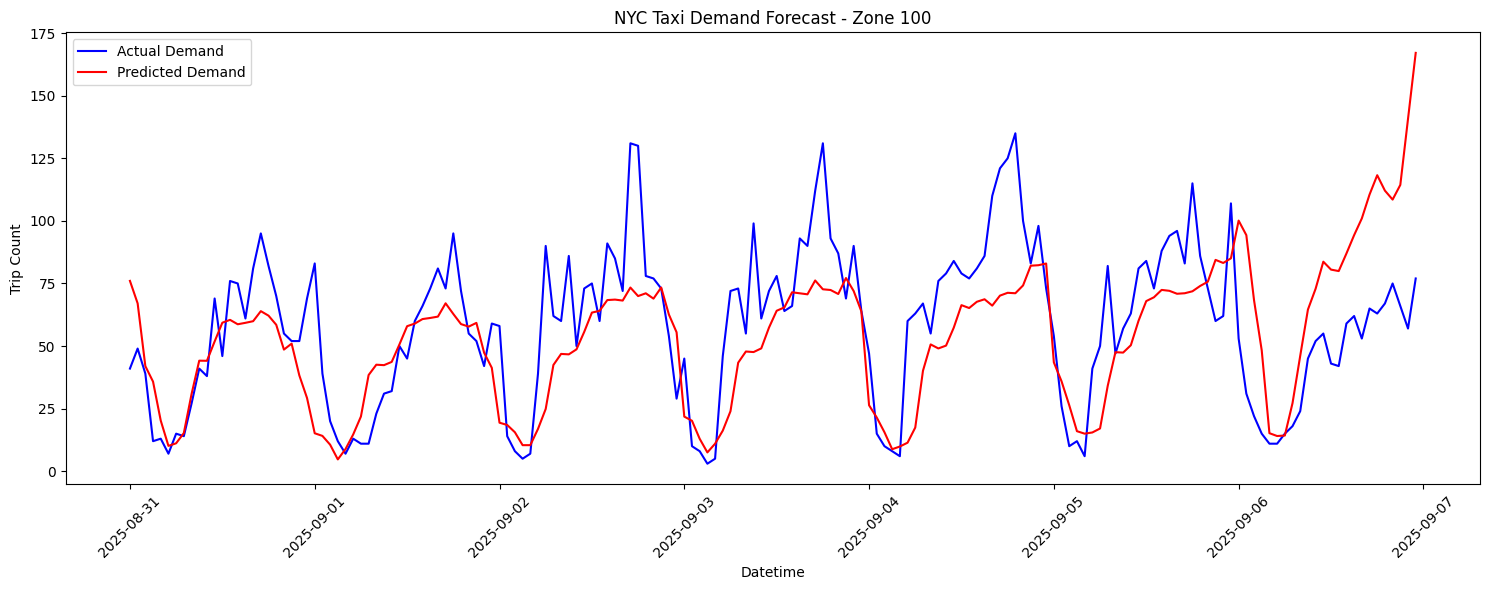

In [17]:
zone_id = 100
zone_test = test[test["zone_id"] == zone_id][['zone_id', 'pickup_datetime', 'trip_count']]
zone_test.sort_values(['zone_id', 'pickup_datetime'], inplace=True)
zone_test["pickup_datetime"] = pd.to_datetime(zone_test["pickup_datetime"])
zone_test = zone_test[:168]
zone_test.reset_index(drop=True, inplace=True)
forecast_7d_copy = forecast_7d[forecast_7d["zone_id"] == zone_id]["predicted_trip_count"].copy()
forecast_7d_copy.reset_index(drop=True, inplace=True)
zone_test["predicted_trip_count"] = forecast_7d_copy
zone_test.set_index('pickup_datetime', inplace=True)


plt.figure(figsize=(15,6))

plt.plot(zone_test["trip_count"],
         label="Actual Demand", color="blue")

plt.plot(zone_test["predicted_trip_count"],
         label="Predicted Demand", color="red")

plt.title(f"NYC Taxi Demand Forecast - Zone {zone_id}")
plt.xlabel("Datetime")
plt.ylabel("Trip Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

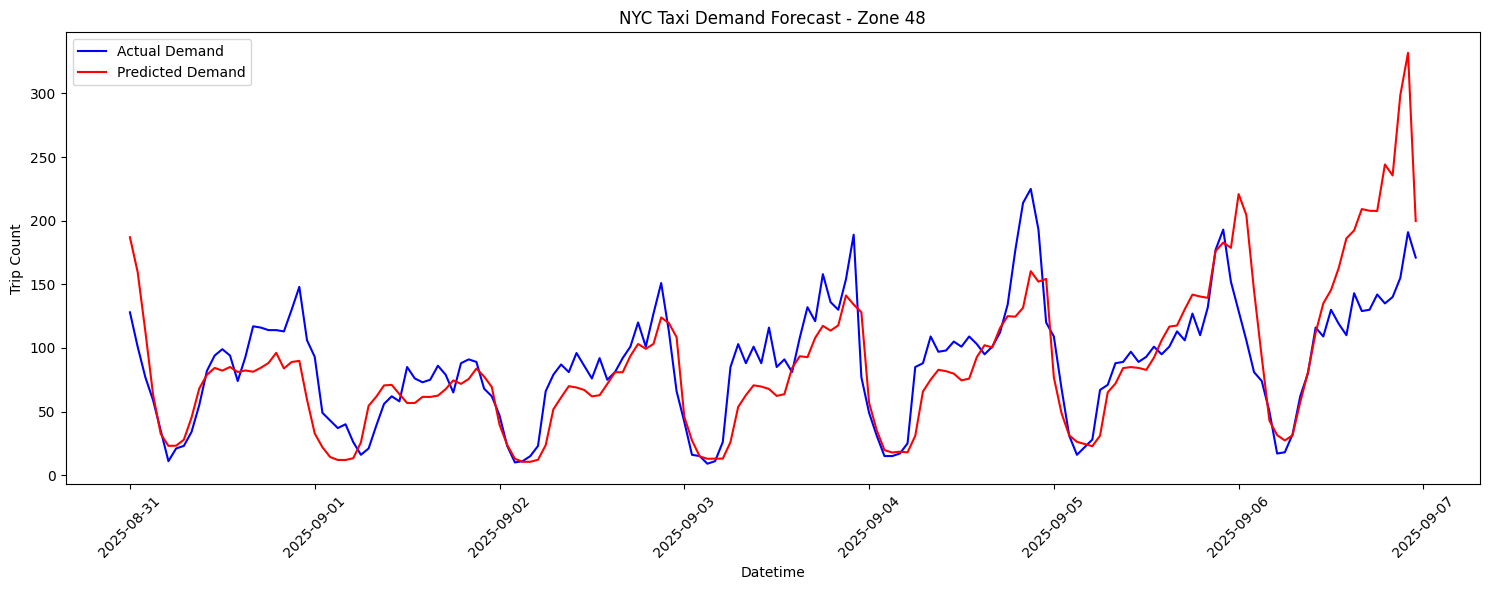

In [18]:
zone_id = 48
zone_test = test[test["zone_id"] == zone_id][['zone_id', 'pickup_datetime', 'trip_count']]
zone_test.sort_values(['zone_id', 'pickup_datetime'], inplace=True)
zone_test["pickup_datetime"] = pd.to_datetime(zone_test["pickup_datetime"])
zone_test = zone_test[:168]
zone_test.reset_index(drop=True, inplace=True)
forecast_7d_copy = forecast_7d[forecast_7d["zone_id"] == zone_id]["predicted_trip_count"].copy()
forecast_7d_copy.reset_index(drop=True, inplace=True)
zone_test["predicted_trip_count"] = forecast_7d_copy
zone_test.set_index('pickup_datetime', inplace=True)


plt.figure(figsize=(15,6))

plt.plot(zone_test["trip_count"],
         label="Actual Demand", color="blue")

plt.plot(zone_test["predicted_trip_count"],
         label="Predicted Demand", color="red")

plt.title(f"NYC Taxi Demand Forecast - Zone {zone_id}")
plt.xlabel("Datetime")
plt.ylabel("Trip Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

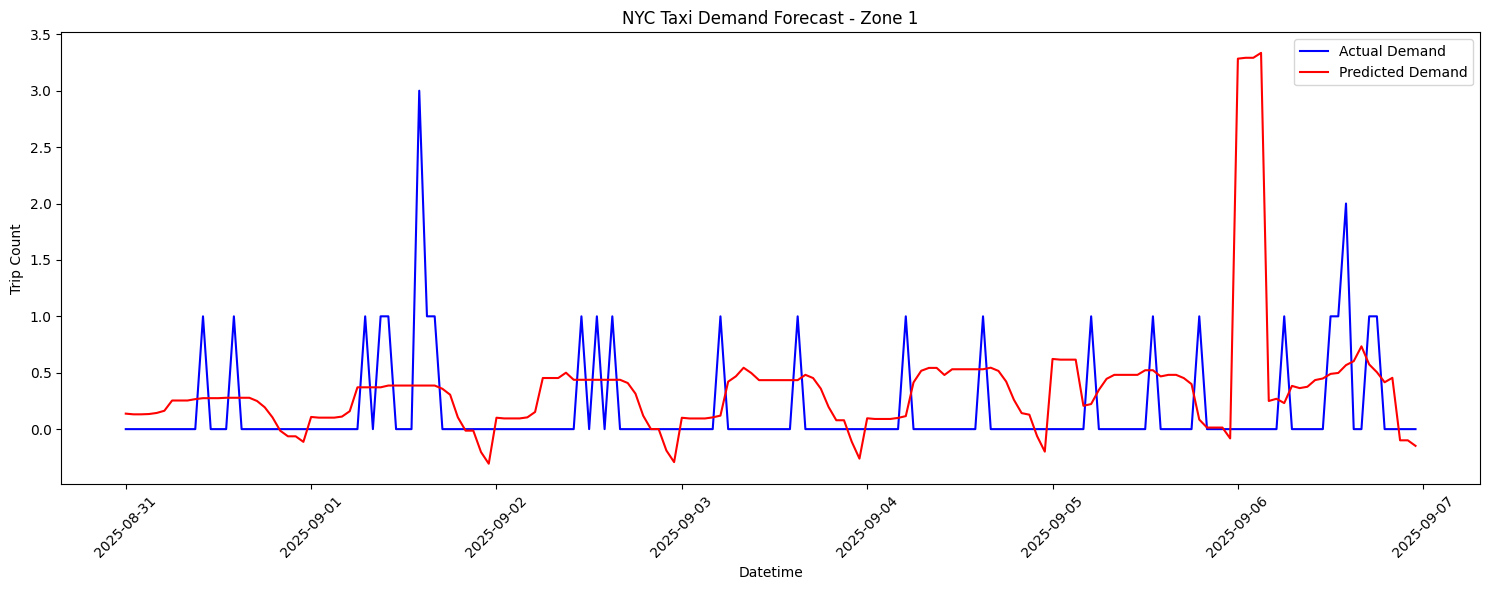

In [19]:
zone_id = 1
zone_test = test[test["zone_id"] == zone_id][['zone_id', 'pickup_datetime', 'trip_count']]
zone_test.sort_values(['zone_id', 'pickup_datetime'], inplace=True)
zone_test["pickup_datetime"] = pd.to_datetime(zone_test["pickup_datetime"])
zone_test = zone_test[:168]
zone_test.reset_index(drop=True, inplace=True)
forecast_7d_copy = forecast_7d[forecast_7d["zone_id"] == zone_id]["predicted_trip_count"].copy()
forecast_7d_copy.reset_index(drop=True, inplace=True)
zone_test["predicted_trip_count"] = forecast_7d_copy
zone_test.set_index('pickup_datetime', inplace=True)


plt.figure(figsize=(15,6))

plt.plot(zone_test["trip_count"],
         label="Actual Demand", color="blue")

plt.plot(zone_test["predicted_trip_count"],
         label="Predicted Demand", color="red")

plt.title(f"NYC Taxi Demand Forecast - Zone {zone_id}")
plt.xlabel("Datetime")
plt.ylabel("Trip Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
pd.DataFrame(data=lgb_model.feature_importances_,
             index=lgb_model.feature_names_in_,
             columns=['Importance']).sort_values('Importance', ascending=False)

,Importance
zone_id,3623
hour,3511
dayofyear,2610
dayofweek,2294
rolling_avg_7d,1810
lag_1,1321
dayofmonth,1052
rolling_std_24h,1021
rolling_avg_24h,782
lag_168,473


In [24]:
month = 3
day = 1
year = 2025

In [43]:
(f"{year}-{month}-{day}")

'2025-3-1'